In [1]:
import scanpy as sc
import matplotlib.pyplot as plt

adata_orig_umap = sc.read_h5ad("output/adata_orig_umap.h5ad")
adata_st_whole_umap = sc.read_h5ad("output/adata_st_whole_umap.h5ad")
adata_st_frag_umap = sc.read_h5ad("output/adata_st_frag_umap.h5ad")
adata_ft_whole_umap = sc.read_h5ad("output/adata_ft_whole_umap.h5ad")
adata_ft_frag_umap = sc.read_h5ad("output/adata_ft_frag_umap.h5ad")

In [2]:
def compute_markers_cluster_supervised(
    adata,
    label_key="cluster_supervised",
    remove_label="Removed",
    method="wilcoxon"
):
    # Filter invalid labels
    adata_filt = adata[
        adata.obs[label_key].notna() &
        (adata.obs[label_key] != remove_label)
    ].copy()

    # Ensure categorical
    adata_filt.obs[label_key] = adata_filt.obs[label_key].astype("category")

    # Rank genes
    sc.tl.rank_genes_groups(
        adata_filt,
        groupby=label_key,
        method=method
    )

    return adata_filt

In [3]:
adata_orig_markers = compute_markers_cluster_supervised(adata_orig_umap)
adata_st_markers   = compute_markers_cluster_supervised(adata_st_whole_umap)
adata_ft_markers   = compute_markers_cluster_supervised(adata_ft_whole_umap)

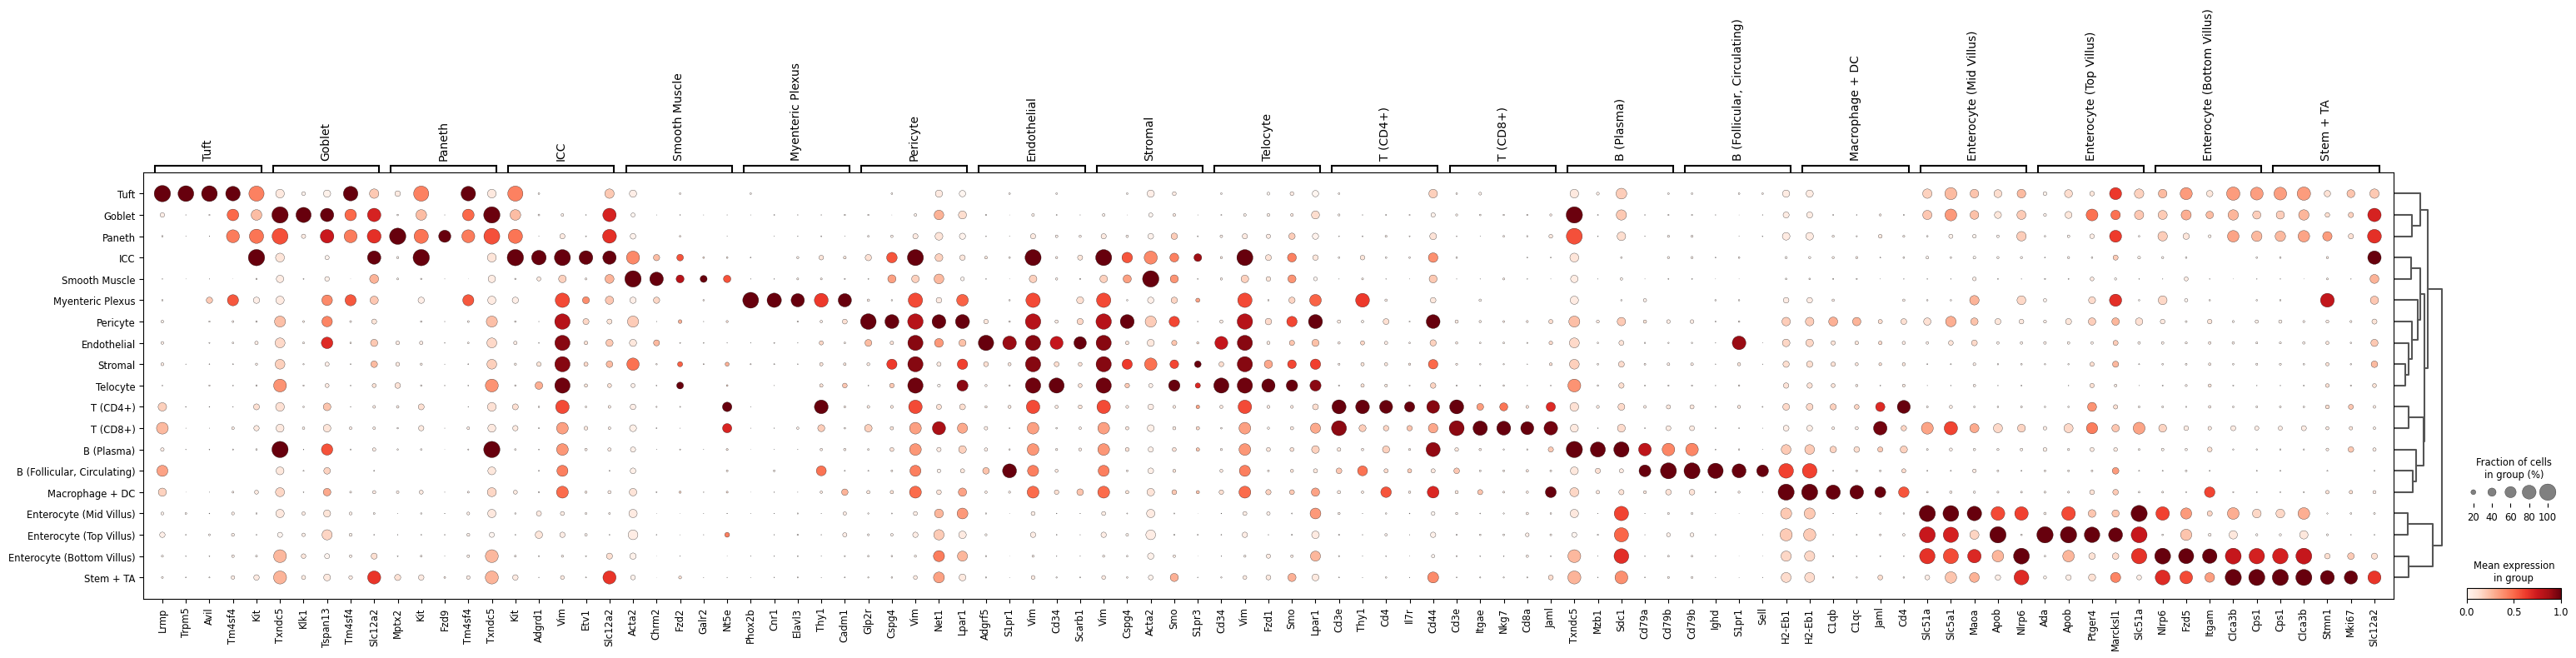

In [4]:
sc.pl.rank_genes_groups_dotplot(
    adata_orig_markers,
    groupby="cluster_supervised",
    n_genes=5,
    standard_scale="var",
    cmap="Reds"
)

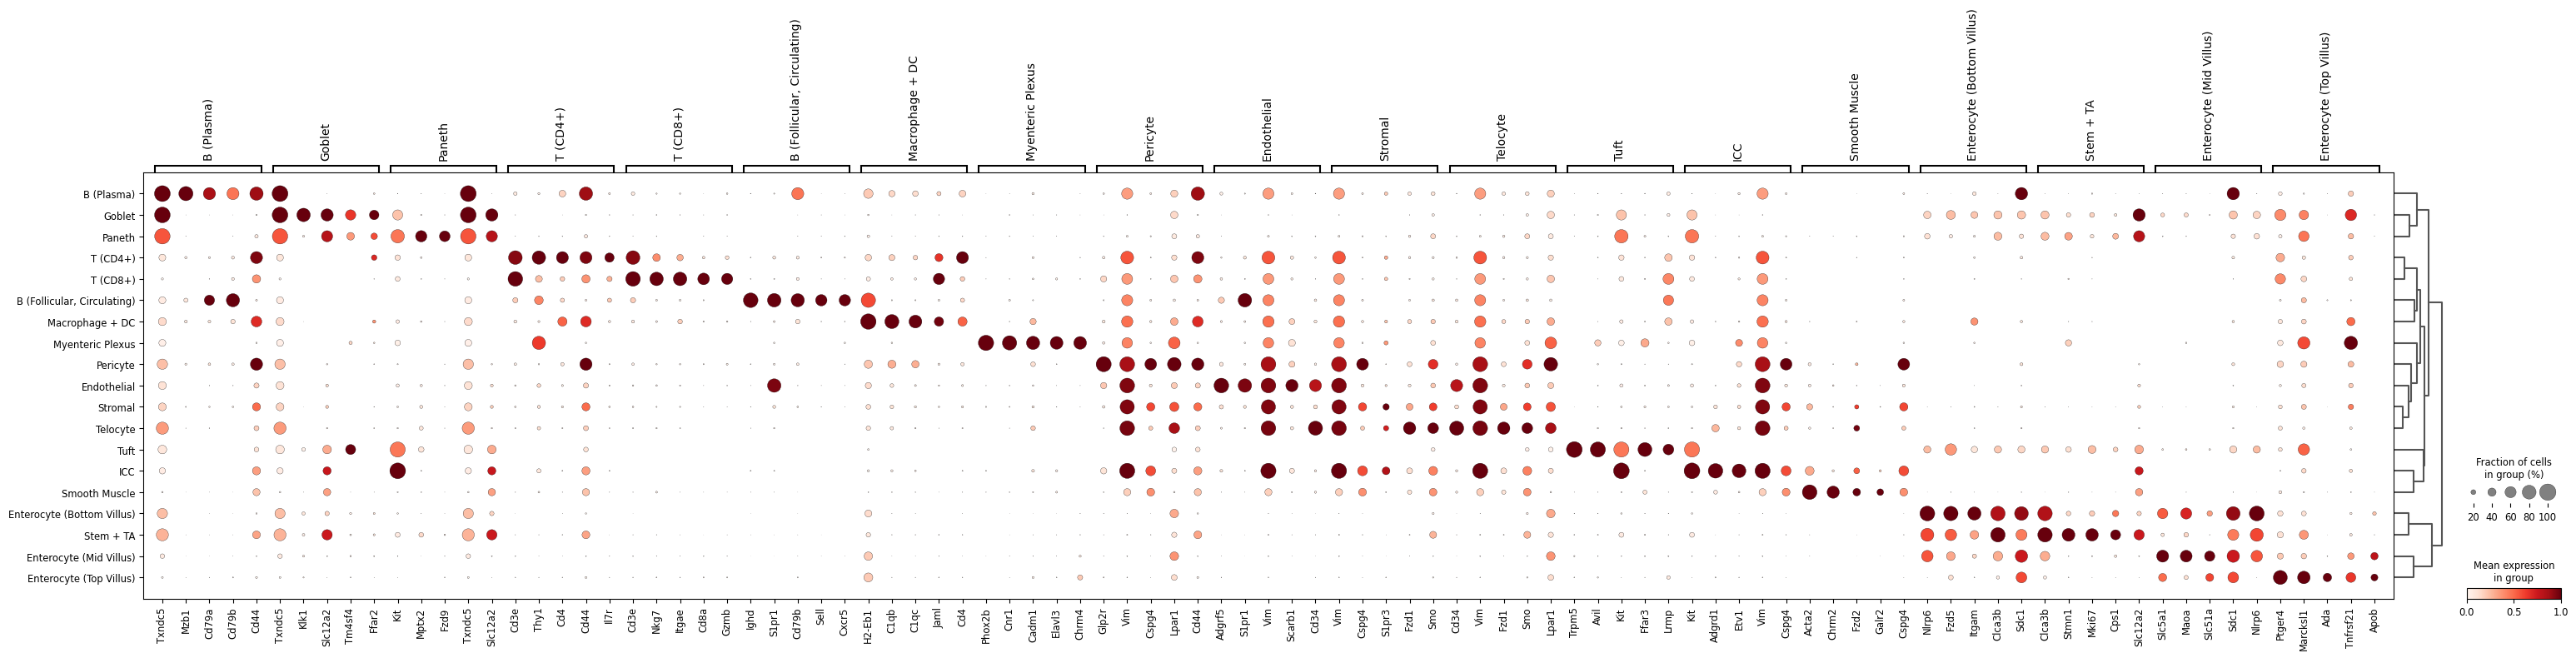

In [5]:
sc.pl.rank_genes_groups_dotplot(
    adata_ft_markers,
    groupby="cluster_supervised",
    n_genes=5,
    standard_scale="var",
    cmap="Reds"
)

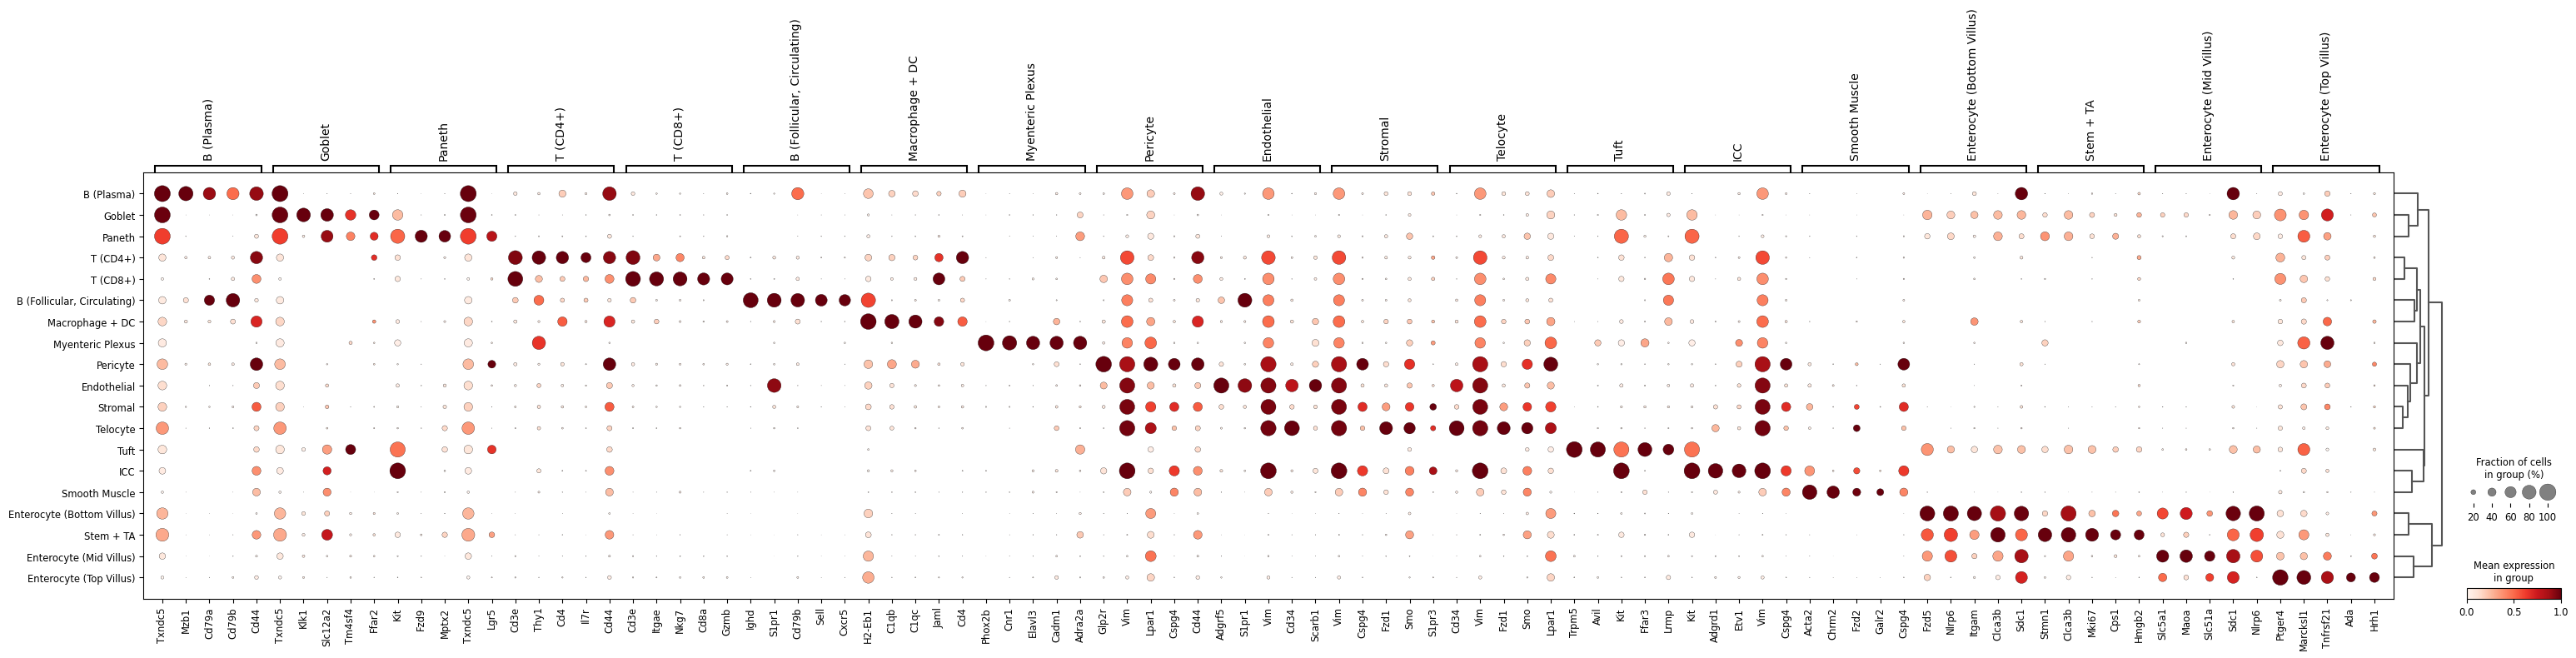

In [6]:
sc.pl.rank_genes_groups_dotplot(
    adata_st_markers,
    groupby="cluster_supervised",
    n_genes=5,
    standard_scale="var",
    cmap="Reds"
)

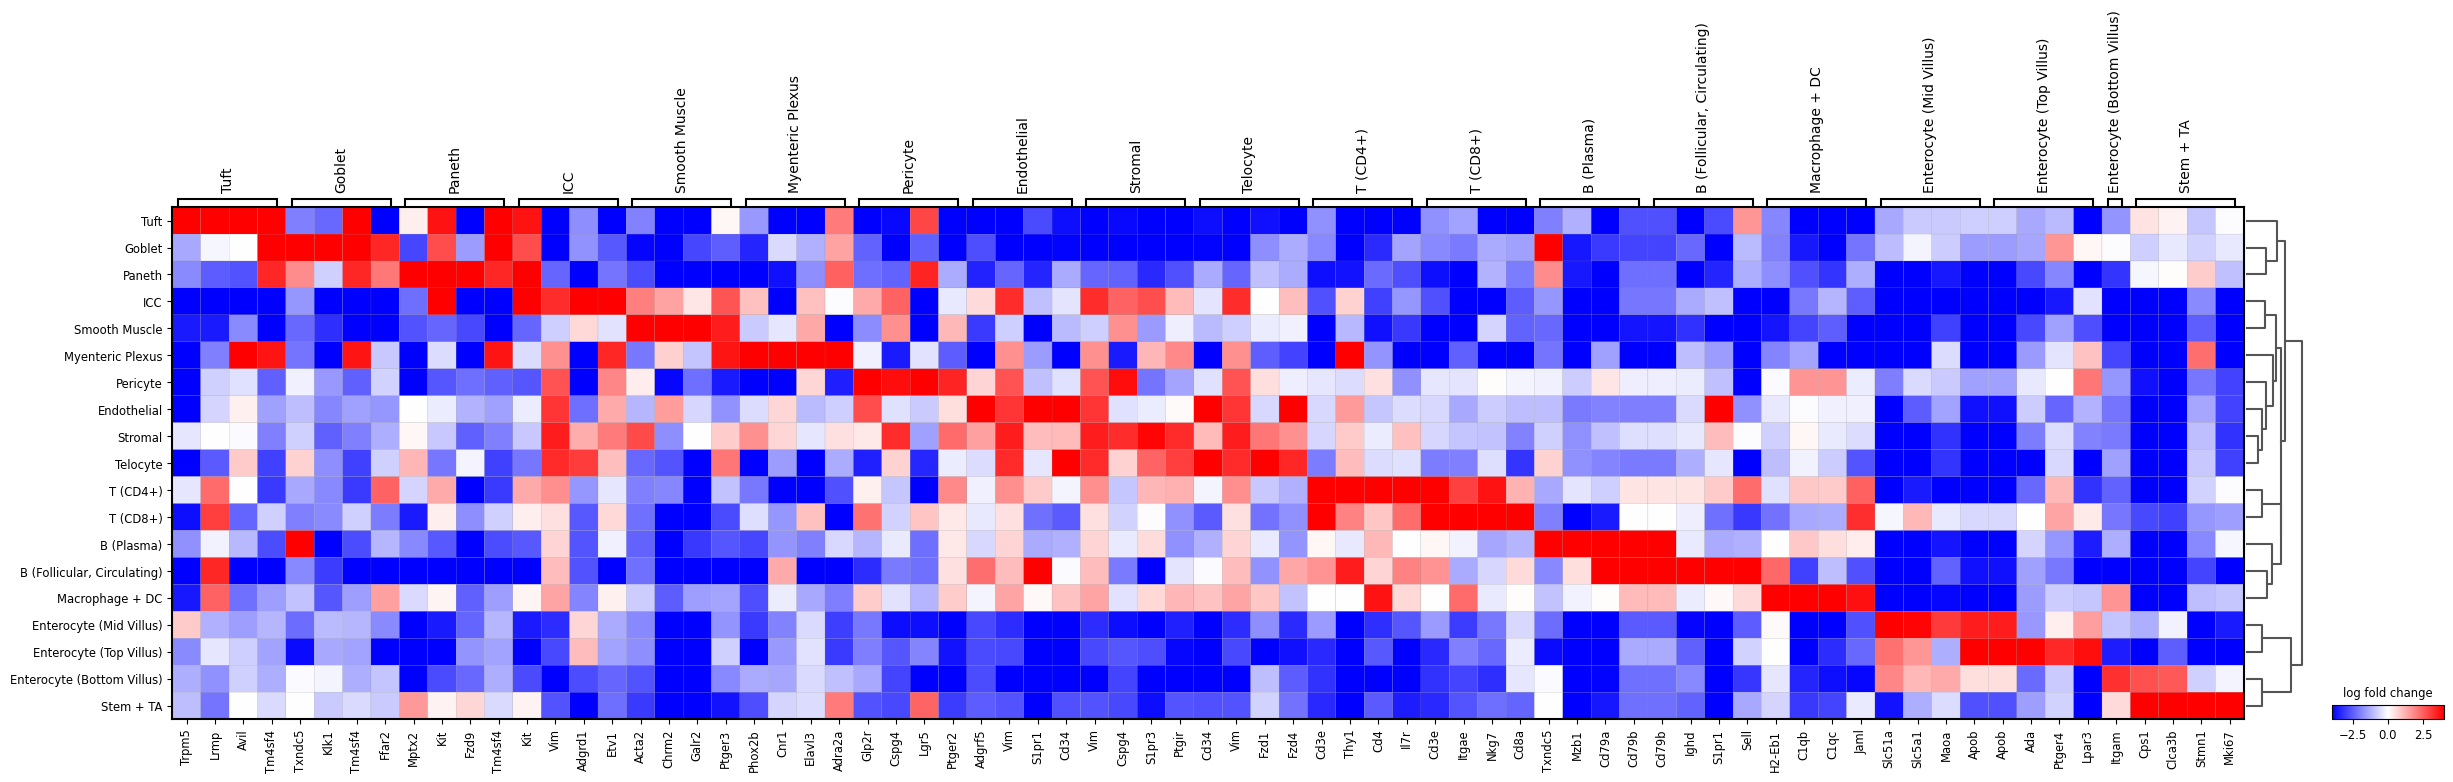

In [11]:
sc.tl.rank_genes_groups(adata_orig_markers, "cluster_supervised")
sc.pl.rank_genes_groups_matrixplot(
    adata_orig_markers,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=3,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/mouse_gut_baysor_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()

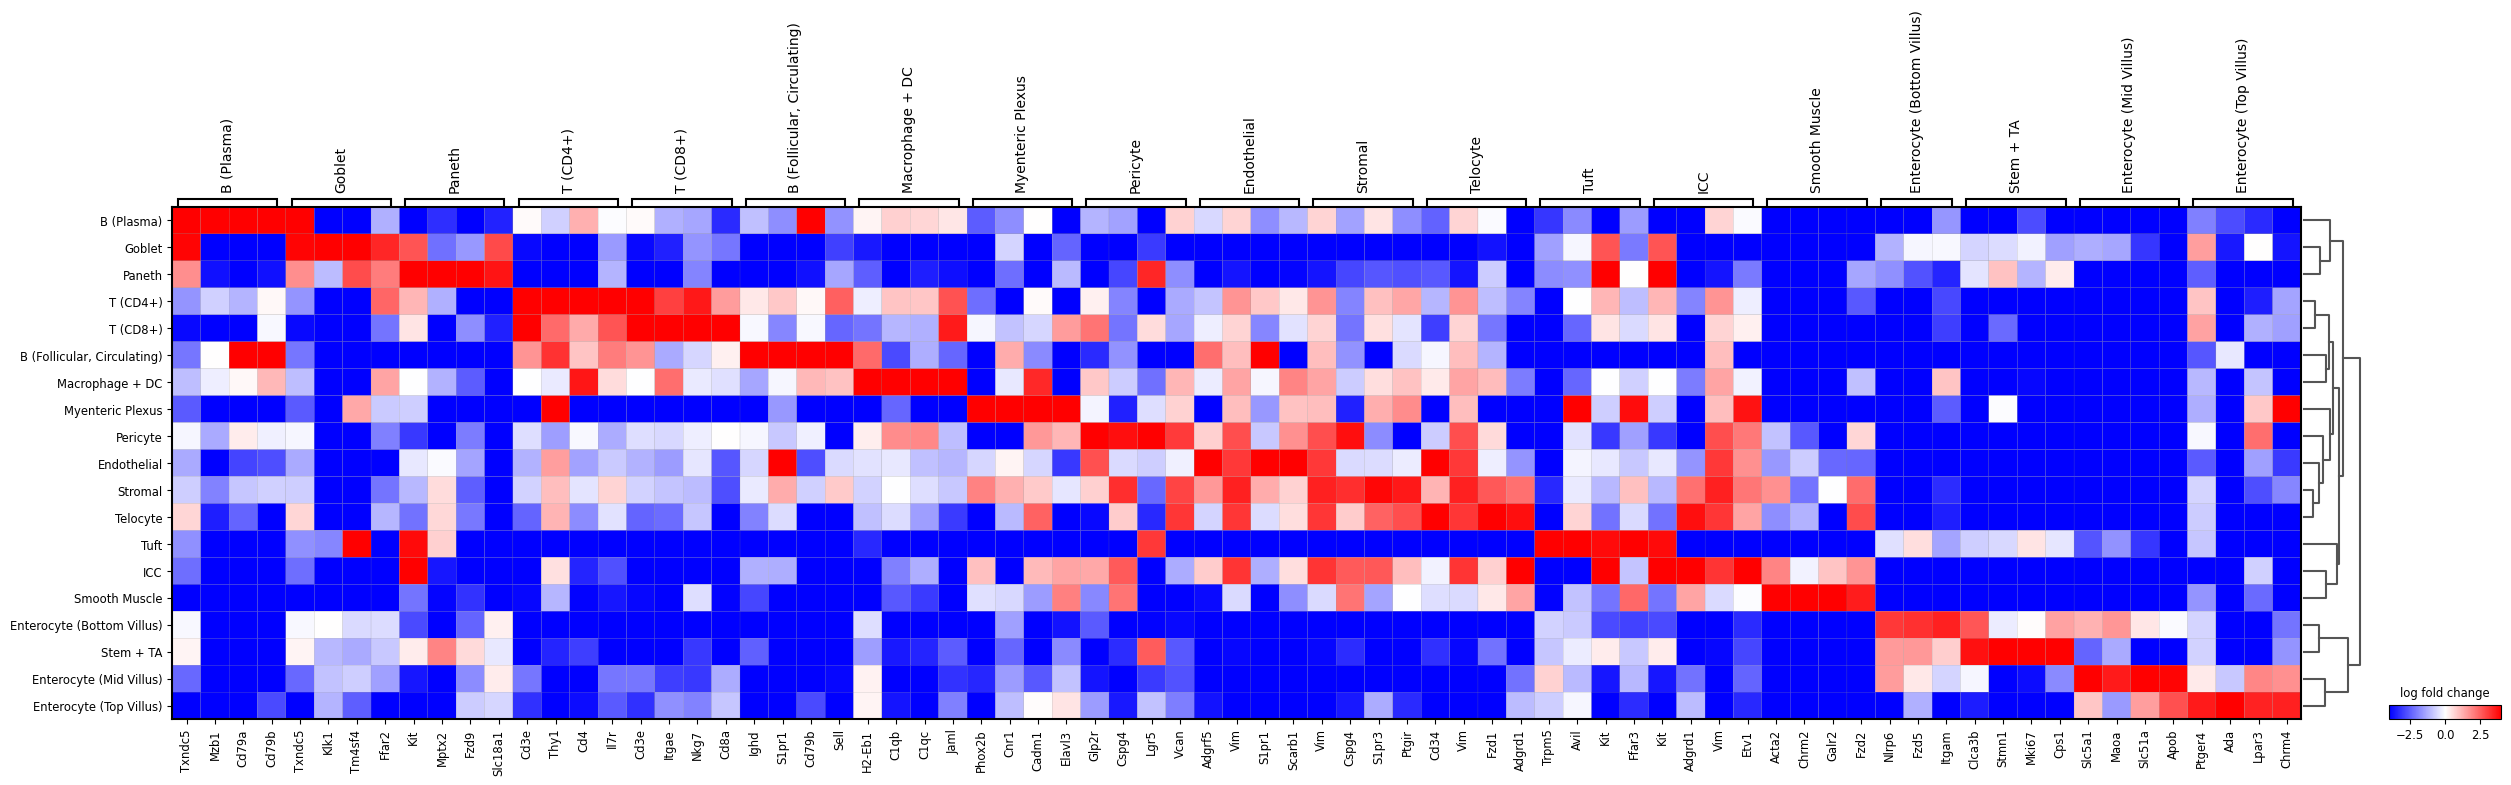

In [12]:
sc.tl.rank_genes_groups(adata_ft_markers, "cluster_supervised")
sc.pl.rank_genes_groups_matrixplot(
    adata_ft_markers,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=3,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/mouse_gut_finetuned_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()

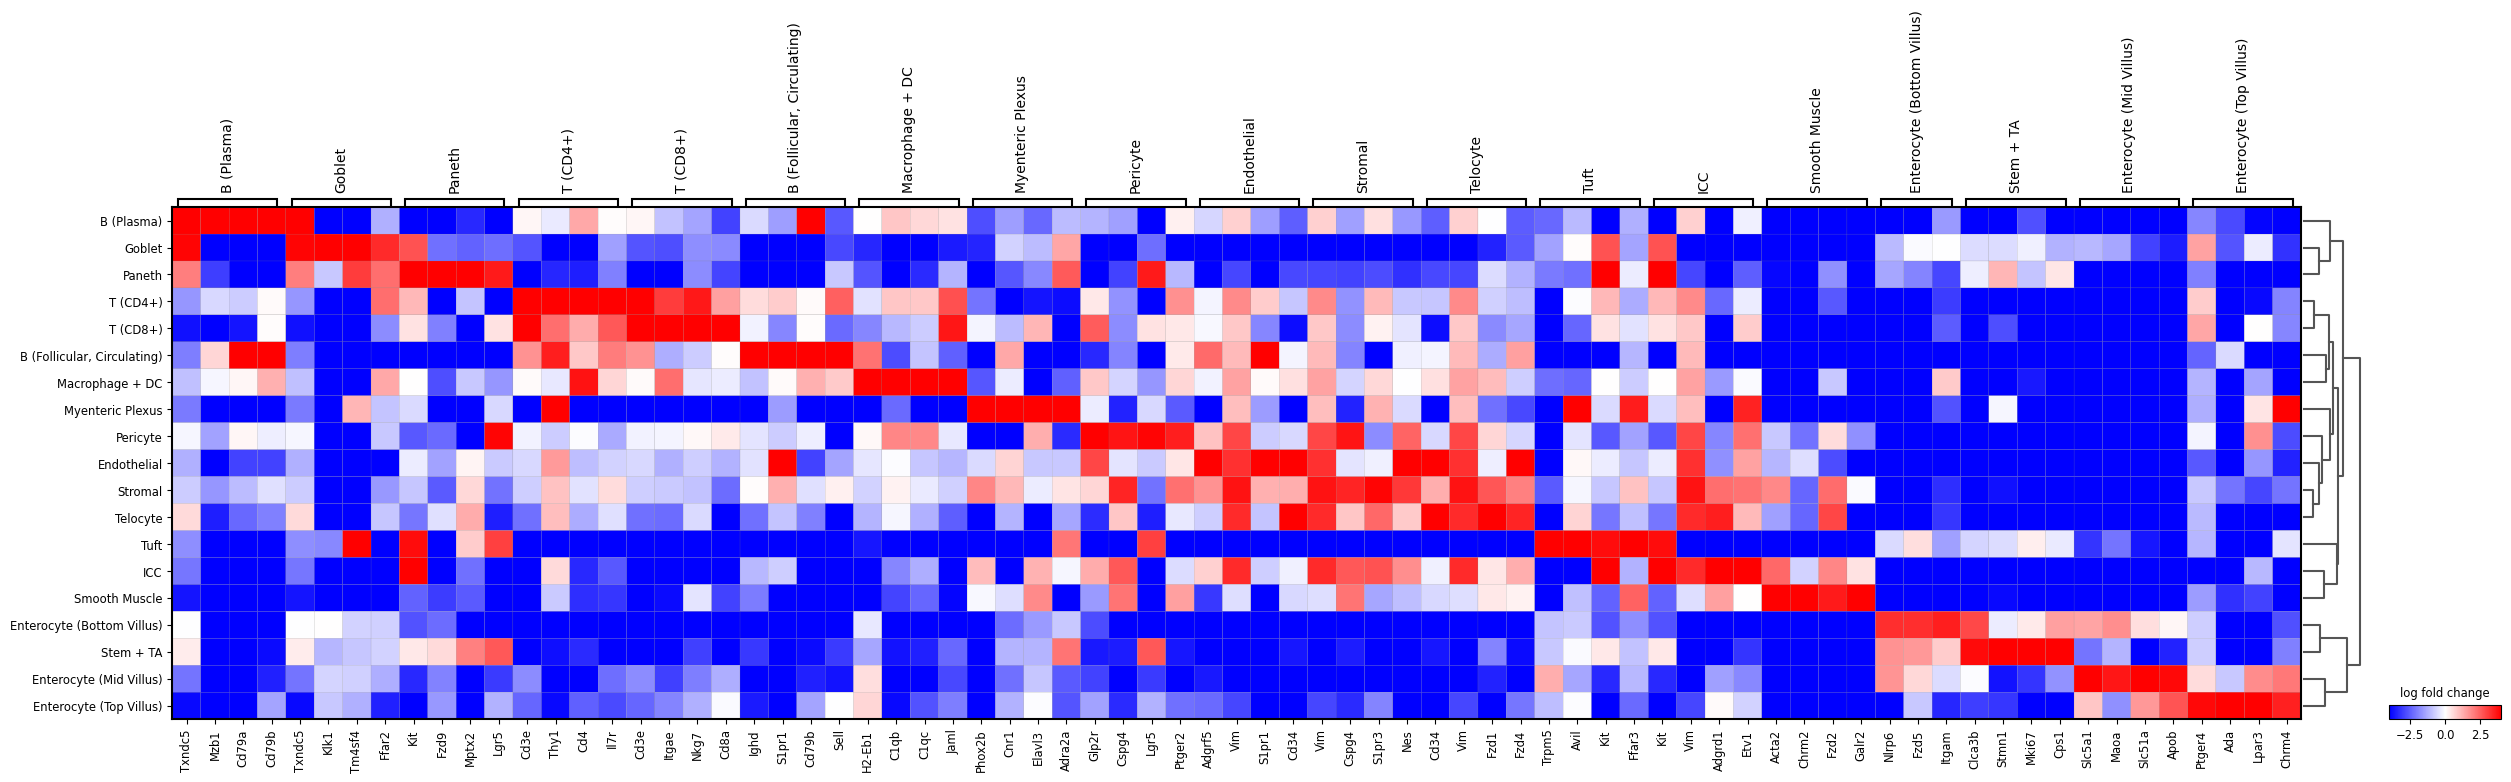

In [13]:
sc.tl.rank_genes_groups(adata_st_markers, "cluster_supervised")
sc.pl.rank_genes_groups_matrixplot(
    adata_st_markers,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=3,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/mouse_gut_stitched_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()

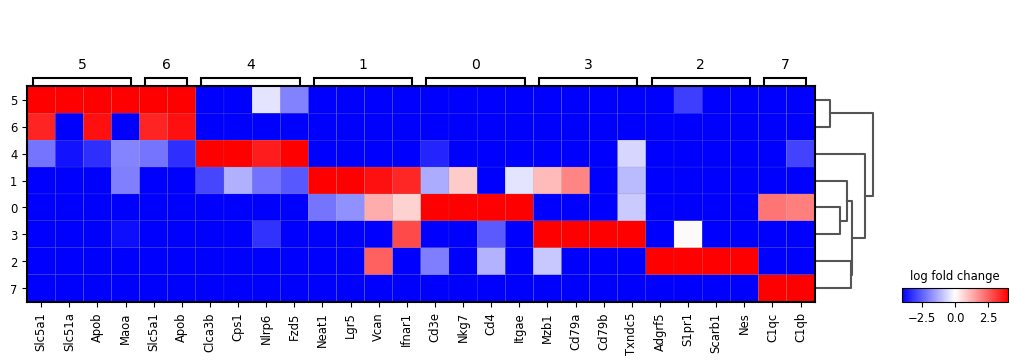

In [16]:
sc.tl.rank_genes_groups(adata_ft_frag_umap, "_leiden")
sc.pl.rank_genes_groups_matrixplot(
    adata_ft_frag_umap,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=3,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/mouse_gut_partial_pseudocell_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()